<a href="https://colab.research.google.com/github/adyogyy-creator/ady.ogy.ipynb/blob/main/V1_Circuit_Parser_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# V1 - Circuit Parser Experiment

netlist = """
AND gate1 a b n1
OR gate2 n1 c out
"""

def parse_netlist(netlist_text):
    gates = []

    for line in netlist_text.strip().splitlines():
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) >= 4:
            gate_type = parts[0]
            gate_name = parts[1]
            inputs = parts[2:-1]
            output = parts[-1]

            gates.append({
                "type": gate_type,
                "name": gate_name,
                "inputs": inputs,
                "output": output,
            })

    return gates


parsed = parse_netlist(netlist)

for gate in parsed:
    print(gate)

{'type': 'AND', 'name': 'gate1', 'inputs': ['a', 'b'], 'output': 'n1'}
{'type': 'OR', 'name': 'gate2', 'inputs': ['n1', 'c'], 'output': 'out'}


In [ ]:
# V1 - Convert parsed circuit into a graph

import networkx as nx

G = nx.DiGraph()

for gate in parsed:
    gate_name = gate["name"]

    # Add the gate itself
    G.add_node(
        gate_name,
        type=gate["type"]
    )

    # Connect input signals to the gate
    for signal in gate["inputs"]:
        G.add_node(
            signal,
            type="INPUT"
        )

        G.add_edge(signal, gate_name)

    # Connect gate to its output signal
    output = gate["output"]

    G.add_node(
        output,
        type="OUTPUT"
    )

    G.add_edge(gate_name, output)

print("Nodes:", list(G.nodes(data=True)))
print("Edges:", list(G.edges()))

Nodes: [('gate1', {'type': 'AND'}), ('a', {'type': 'INPUT'}), ('b', {'type': 'INPUT'}), ('n1', {'type': 'INPUT'}), ('gate2', {'type': 'OR'}), ('c', {'type': 'INPUT'}), ('out', {'type': 'OUTPUT'})]
Edges: [('gate1', 'n1'), ('a', 'gate1'), ('b', 'gate1'), ('n1', 'gate2'), ('gate2', 'out'), ('c', 'gate2')]


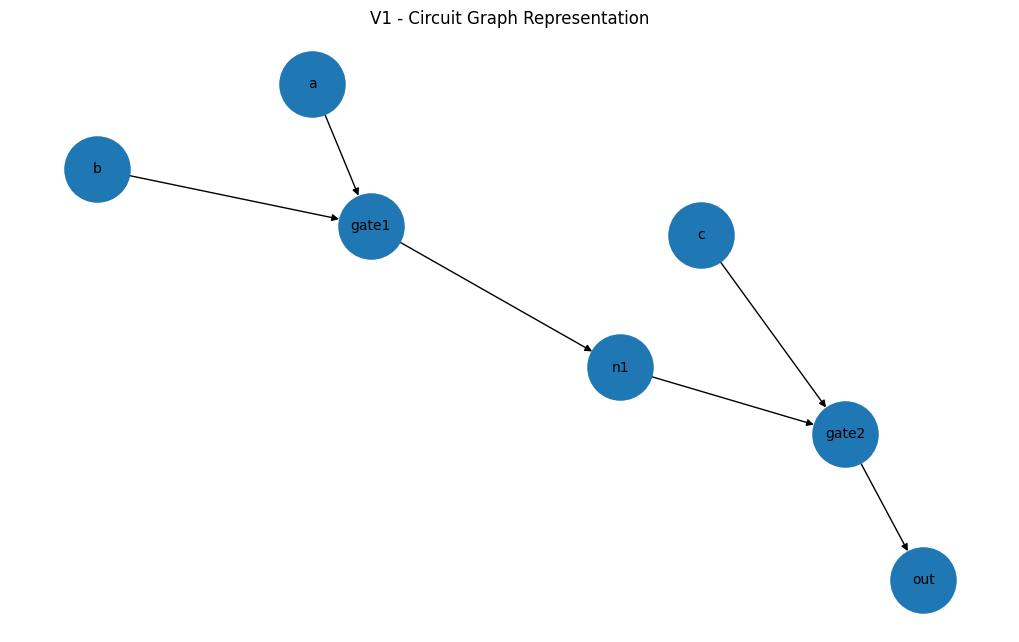

In [ ]:
# V1 - Visualize the circuit graph

import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 6))

# Layout for a readable circuit-style graph
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2200,
    arrows=True,
    font_size=10
)

plt.title("V1 - Circuit Graph Representation")
plt.axis("off")
plt.show()